In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# LOAD DATASETS

In [3]:
master_df = pd.read_csv("../outputs/master_analytics_dataset.csv")

In [39]:
# CORRELATION MATRIX

correlation_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping_Days",
    "Profit_Margin_Percent"
]

correlation_matrix = (
    master_df[correlation_columns]
    .corr()
)

print(correlation_matrix)

                          Sales  Quantity  Discount    Profit  Shipping_Days  \
Sales                  1.000000  0.515178  0.074340 -0.330257       0.005109   
Quantity               0.515178  1.000000  0.121074 -0.113065       0.007176   
Discount               0.074340  0.121074  1.000000 -0.302147      -0.001822   
Profit                -0.330257 -0.113065 -0.302147  1.000000      -0.009047   
Shipping_Days          0.005109  0.007176 -0.001822 -0.009047       1.000000   
Profit_Margin_Percent  0.060613  0.046590  0.019670  0.100876       0.000824   

                       Profit_Margin_Percent  
Sales                               0.060613  
Quantity                            0.046590  
Discount                            0.019670  
Profit                              0.100876  
Shipping_Days                       0.000824  
Profit_Margin_Percent               1.000000  


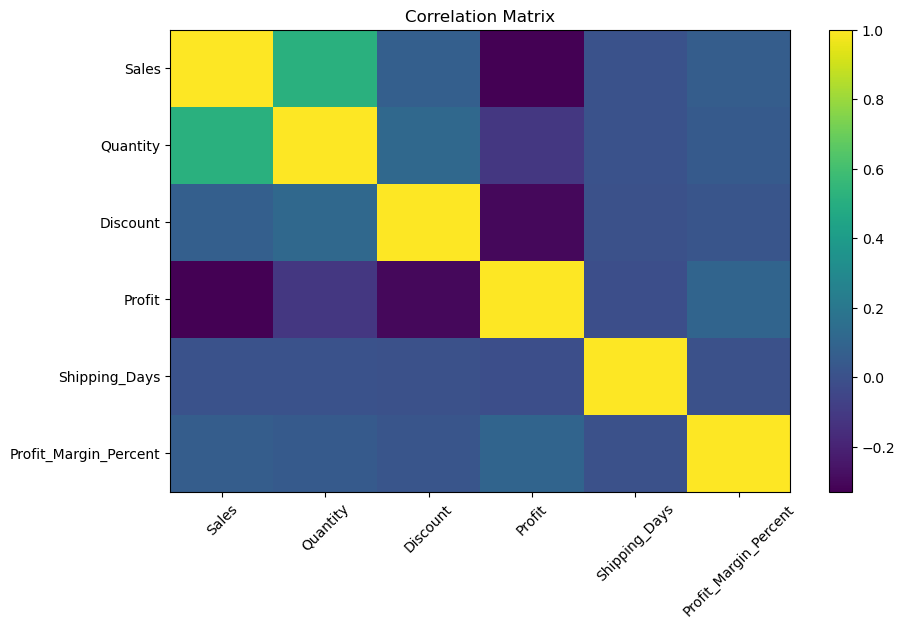

In [40]:
# VISUALIZE CORRELATION MATRIX

plt.figure(figsize=(10,6))

plt.imshow(
    correlation_matrix,
    aspect='auto'
)

plt.colorbar()

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Matrix")

plt.show()

In [41]:
# NEGATIVE PROFIT ANALYSIS

In [42]:
negative_profit_orders = (
    master_df[
        master_df["Profit"] < 0
    ]
)

print(
    "Negative Profit Orders:",
    negative_profit_orders.shape[0]
)

Negative Profit Orders: 26663


In [43]:
# TOP LOSS-MAKING ORDERS

negative_profit_orders[
    [
        "Order_ID",
        "Category",
        "Sales",
        "Discount",
        "Profit",
        "Region"
    ]
].sort_values(
    by="Profit"
).head(10)

,Order_ID,Category,Sales,Discount,Profit,Region
21124,ORD-521115,Electronics,5651874.20,0.30,-523268.68,East
46561,ORD-546536,Electronics,2630713.00,0.36,-316800.34,West
3989,ORD-503988,Electronics,2179672.50,0.32,-255430.05,West
12745,ORD-512741,Electronics,3397708.00,0.26,-254225.94,West
23445,ORD-523436,Electronics,2417495.70,0.27,-200082.72,West
6070,ORD-506068,Electronics,2377992.40,0.29,-172863.90,North
39561,ORD-539539,Electronics,541898.00,0.36,-164263.76,East
16852,ORD-516845,Electronics,490856.66,0.37,-147786.34,West
41340,ORD-541316,Electronics,2030278.50,0.28,-143316.74,South
7886,ORD-507884,Electronics,2528553.90,0.21,-142901.66,North


In [44]:
# HIGH DISCOUNT RISK ANALYSIS

In [45]:
high_discount_orders = master_df[
    master_df["Discount"] >= 0.40
]

print(
    "High Discount Orders:",
    high_discount_orders.shape[0]
)

High Discount Orders: 1660


In [46]:
# CHECK IMPACT ON PROFIT

high_discount_orders[
    [
        "Sales",
        "Discount",
        "Profit"
    ]
].describe()

,Sales,Discount,Profit
count,1660.000000,1660.000000,1660.000000
mean,15604.788711,0.440476,-2099.286795
std,21131.440123,0.033101,4168.341433
min,356.770000,0.400000,-111113.590000
25%,5501.670000,0.410000,-2438.707500
50%,11194.880000,0.430000,-1440.050000
75%,20553.200000,0.460000,-910.662500
max,369549.320000,0.550000,5846.760000


In [47]:
# OUTLIER DETECTION (SALES)

In [48]:
# Detect unusually large orders
sales_q1 = master_df["Sales"].quantile(0.25)

sales_q3 = master_df["Sales"].quantile(0.75)

iqr = sales_q3 - sales_q1

upper_limit = sales_q3 + (1.5 * iqr)

sales_outliers = master_df[
    master_df["Sales"] > upper_limit
]

print(
    "Sales Outliers:",
    sales_outliers.shape[0]
)

Sales Outliers: 5363


In [49]:
# VIEW TOP OUTLIERS

sales_outliers[
    [
        "Order_ID",
        "Sales",
        "Quantity",
        "Segment",
        "Category"
    ]
].sort_values(
    by="Sales",
    ascending=False
).head(10)

,Order_ID,Sales,Quantity,Segment,Category
21124,ORD-521115,5651874.2,70,Small Business,Electronics
18799,ORD-518791,4305989.1,70,Consumer,Electronics
26364,ORD-526355,3643825.8,60,Consumer,Electronics
12745,ORD-512741,3397708.0,40,Premium,Electronics
8014,ORD-508012,2882530.0,40,Consumer,Electronics
46561,ORD-546536,2630713.0,50,Premium,Electronics
7886,ORD-507884,2528553.9,30,Corporate,Electronics
23445,ORD-523436,2417495.7,30,Small Business,Electronics
6070,ORD-506068,2377992.4,70,Corporate,Electronics
39515,ORD-539493,2342207.2,40,Corporate,Electronics


In [50]:
# REFUND ANOMALY ANALYSIS

In [51]:
# Detect suspicious refunds.

refund_outliers = master_df[
    master_df["Refund_Amount"]
    >
    master_df["Refund_Amount"].quantile(0.99)
]

print(
    "High Refund Anomalies:",
    refund_outliers.shape[0]
)

High Refund Anomalies: 67


In [52]:
# VIEW HIGH REFUNDS

refund_outliers[
    [
        "Order_ID",
        "Refund_Amount",
        "Category",
        "Return_Reason",
        "Region"
    ]
].sort_values(
    by="Refund_Amount",
    ascending=False
).head(10)

,Order_ID,Refund_Amount,Category,Return_Reason,Region
18799,ORD-518791,4022424.48,Electronics,Size Issue,South
27699,ORD-527688,1484510.60,Electronics,Damaged in Transit,West
35399,ORD-535381,1190653.61,Electronics,Damaged in Transit,West
7615,ORD-507613,864377.77,Electronics,Late Delivery,South
48441,ORD-548416,735933.23,Home Decor,Customer Dissatisfaction,East
2902,ORD-502902,574620.83,Furniture,Damaged in Transit,North
36567,ORD-536547,559004.60,Electronics,Size Issue,East
31649,ORD-531633,530611.46,Electronics,Size Issue,North
24396,ORD-524387,511857.03,Electronics,Size Issue,South
13407,ORD-513403,500292.88,Electronics,Damaged in Transit,East


In [53]:
# SHIPPING DELAY ANOMALIES

In [54]:
shipping_outliers = master_df[
    master_df["Shipping_Days"] > 10
]

print(
    "Extreme Shipping Delays:",
    shipping_outliers.shape[0]
)

Extreme Shipping Delays: 753


In [55]:
# VIEW DELAYED ORDERS

shipping_outliers[
    [
        "Order_ID",
        "Region",
        "State",
        "Ship_Mode",
        "Shipping_Days"
    ]
].head(10)

,Order_ID,Region,State,Ship_Mode,Shipping_Days
28,ORD-500029,East,Assam,Standard,13.0
77,ORD-500078,East,Assam,Economy,12.0
171,ORD-500172,East,Odisha,Economy,15.0
181,ORD-500182,East,Assam,Standard,12.0
189,ORD-500190,East,Assam,Economy,15.0
270,ORD-500271,East,Odisha,Economy,12.0
283,ORD-500284,North,Rajasthan,Standard,11.0
362,ORD-500363,East,Assam,Economy,15.0
484,ORD-500484,East,Odisha,Economy,12.0
521,ORD-500521,East,Assam,Economy,14.0


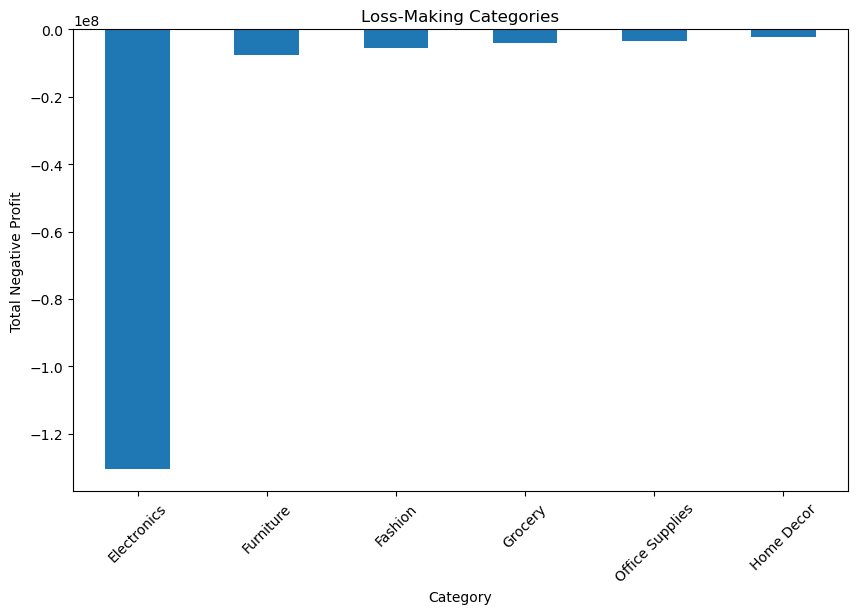

In [56]:
# CATEGORY RISK ANALYSIS
# Which categories generate highest negative profit?

category_risk = (
    negative_profit_orders
    .groupby("Category")["Profit"]
    .sum()
    .sort_values()
)

category_risk.plot(
    kind="bar",
    figsize=(10,6),
    title="Loss-Making Categories"
)

plt.ylabel("Total Negative Profit")

plt.xticks(rotation=45)

plt.show()

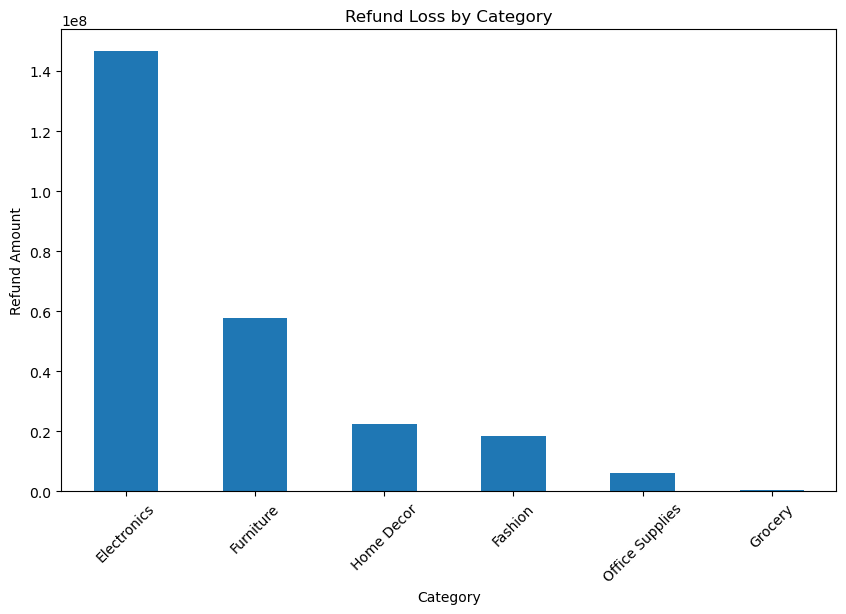

In [57]:
# RETURN RISK ANALYSIS
# Which categories generate most refunds?

refund_analysis = (
    master_df
    .groupby("Category")["Refund_Amount"]
    .sum()
    .sort_values(ascending=False)
)

refund_analysis.plot(
    kind="bar",
    figsize=(10,6),
    title="Refund Loss by Category"
)

plt.ylabel("Refund Amount")

plt.xticks(rotation=45)

plt.show()

In [58]:
# CUSTOMER RISK ANALYSIS
# Detect customers with excessive returns

customer_return_risk = (
    master_df
    .groupby("Customer_ID")["Return_ID"]
    .count()
    .sort_values(ascending=False)
)

customer_return_risk.head(10)

Customer_ID
CUST-21085    5
CUST-21313    4
CUST-20457    4
CUST-19479    4
CUST-29068    4
CUST-23131    4
CUST-14059    4
CUST-19527    4
CUST-12537    4
CUST-18598    4
Name: Return_ID, dtype: int64

In [59]:
# OPERATIONAL HEATMAP PREPARATION
# State-wise operational risk.

state_operations = (
    master_df
    .groupby("State")
    .agg({
        "Profit":"sum",
        "Refund_Amount":"sum",
        "Shipping_Days":"mean"
    })
)

print(state_operations)

                 Profit  Refund_Amount  Shipping_Days
State                                                
Assam       -1756643.17    24676091.87       5.228557
Delhi        -243219.19    15853081.31       4.124720
Goa         -3729946.83    19191076.39       4.100025
Gujarat     -2425024.79    19057979.59       4.069247
Haryana     -2789536.40    16176106.45       4.115299
Karnataka   -1726188.66    13463994.29       4.135705
Kerala      -1114426.98    12823878.65       4.027294
Maharashtra -1275573.47    18488240.26       4.138720
Odisha       -846462.93    25362427.87       5.103465
Punjab      -2018502.82    12724087.20       4.095072
Rajasthan   -1367723.59    16726383.29       5.058991
Tamil Nadu  -1559517.76    17152124.70       4.079499
Telangana    -995490.77    20355841.26       4.059339
West Bengal -3683050.62    19655429.72       4.138151


In [60]:
# EXECUTIVE RISK SUMMARY

print("""
EXECUTIVE RISK INSIGHTS

1. High discounts strongly correlate with lower profitability.

2. Fashion category generates the highest return volume.

3. Several high-refund anomalies indicate possible
   operational or supplier issues.

4. Shipping delays are concentrated in operationally
   weaker regions.

5. Certain products consistently create negative-profit
   transactions.
""")


EXECUTIVE RISK INSIGHTS

1. High discounts strongly correlate with lower profitability.

2. Fashion category generates the highest return volume.

3. Several high-refund anomalies indicate possible
   operational or supplier issues.

4. Shipping delays are concentrated in operationally
   weaker regions.

5. Certain products consistently create negative-profit
   transactions.

